In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
from scipy.stats import kruskal
from scipy.stats import mannwhitneyu

# 1. Abstract

Overweight and obesity present severe public health challenges, increasing the risk of cardiovascular disease, type 2 diabetes, musculoskeletal disorders, and premature mortality (Obesity: Health Consequences of Being Overweight, n.d.). This study analyzes Global Burden of Disease (GBD) 2021 data to determine whether obesity rates among individuals aged 5–24 are influenced by demographic and geographic factors. Results show a steady annual increase in youth obesity prevalence, with the highest rates among young adults aged 20–24 and females, highlighting the need for targeted public health policies.



Load dataset into Pandas dataframe

In [ ]:
df = pd.read_csv('OB_ONLY.CSV')

# 2. Dataset Description

The dataset used in this project was obtained from the **Global Burden of Disease (GBD) Study 2021**, specifically the **Child and Adolescent Overweight and Obesity Estimates and Forecasts** dataset, coordinated by the **Institute for Health Metrics and Evaluation (IHME)**. This study uses the obesity prevalence subset of the dataset, which contains estimates of annual obesity prevalence among children and adolescents across multiple countries and territories. Each row represents an estimated obesity prevalence for a specific location, year, age group, and sex, together with the corresponding uncertainty intervals and estimated change values.


### 2.1 How the Data Was Collected

The estimates were developed using 1,321 unique sources containing measurements of height and weight collected from 180 countries and territories. These sources included measured and self-reported height and weight data obtained from survey microdata, national reports, and published literature. The collected data were used to estimate age-standardized overweight and obesity prevalence by age group, sex, country, and year. (add citation later)



Because direct observations were not available for every country and year, the GBD Study applied spatiotemporal Gaussian process regression to estimate obesity prevalence while accounting for geographic and temporal trends, resulting in a dataset that consists of modeled estimates rather than direct measurements for every observation. 

### 2.2 Implications of Data

The GBD 2021 dataset is a reliable resource for global obesity analysis because it applies a standardized methodology to estimate obesity prevalence across countries and years. The use of consistent obesity classification criteria and statistical modeling methods improves comparability between regions despite differences in available health data.

Despite its strengths, the dataset has several limitations that should be considered when interpreting the results. Data availability and quality vary across countries, as some regions have more comprehensive health surveys and measurements than others. Consequently, estimates for countries with limited observations rely more heavily on statistical modeling rather than direct measurements, which may increase uncertainty in those estimates.

The inclusion of self-reported height and weight data from some sources may also introduce measurement bias, as these values may differ from directly measured values. Although adjustments were applied during dataset development to address differences between measured and self-reported data, some residual bias may remain.

### 2.3 Scope

This study analyzes only the historical obesity prevalence estimates from 1990 to 2021. Overweight prevalence and forecasted estimates from 2022 to 2050 were excluded from the analysis. The forecasted values were omitted because they are model-based projections intended to represent possible future trends under current conditions rather than observed historical estimates.

### 2.4 Structure of Data
The dataset contains 15 variables, described as follows:

*   `metric` - The type of metric used for the estimate
*   `location_level` - Geographic level of the estimate (e.g., country or region)


*   `location_name` - Name of the location
*   `location_id` - A unique numeric identifier for each location


*   `Sex` - Gender category of the estimate
*   `sex_id` - A unique numeric identifier for sex category

*   `age_group_name` - The age group of the population
*   `age_group_id` - A unique numeric identifier for age group

*   `year_id` - Year of the estimate
*   `mean_prev` - Estimated mean prevalence of obesity

* `lower_prev` - Lower bound (2.5%) of the prevalence estimate
* `upper_prev` - Upper bound (97.5%) of the prevalence estimate

* `mean_change` - Estimated mean percentage change in prevalence over time

* `lower_change` - Lower bound of the percentage change estimate

* `upper_change` - Upper bound of the percentage change estimate

In [25]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 170556 entries, 0 to 170555
Data columns (total 15 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   metric          170556 non-null  object 
 1   location_level  170556 non-null  object 
 2   location_name   170556 non-null  object 
 3   location_id     170556 non-null  int64  
 4   Sex             170556 non-null  object 
 5   sex_id          170556 non-null  int64  
 6   age_group_name  170556 non-null  object 
 7   age_group_id    170556 non-null  int64  
 8   year_id         170556 non-null  int64  
 9   mean_prev       170556 non-null  float64
 10  lower_prev      170556 non-null  float64
 11  upper_prev      170556 non-null  float64
 12  mean_change     170556 non-null  float64
 13  lower_change    170556 non-null  float64
 14  upper_change    170556 non-null  float64
dtypes: float64(6), int64(4), object(5)
memory usage: 19.5+ MB
None


In [26]:
df.describe()

,location_id,sex_id,age_group_id,year_id,mean_prev,lower_prev,upper_prev,mean_change,lower_change,upper_change
count,170556.000000,170556.000000,170556.000000,170556.000000,170556.000000,170556.000000,170556.000000,170556.000000,170556.000000,170556.000000
mean,131.111588,2.000000,7.500000,2020.000000,0.114450,0.078241,0.155810,1.983253,0.804418,3.730333
std,95.053124,0.816499,1.118037,17.606868,0.116069,0.087346,0.143422,1.511857,0.763589,3.213386
min,1.000000,1.000000,6.000000,1990.000000,0.000877,0.000430,0.001613,0.180354,-0.516354,0.263154
25%,61.000000,1.000000,6.750000,2005.000000,0.036235,0.022137,0.054603,0.992254,0.314045,1.574025
50%,119.000000,2.000000,7.500000,2020.000000,0.076123,0.049030,0.110115,1.536092,0.612283,2.610389
75%,177.000000,3.000000,8.250000,2035.000000,0.148766,0.099207,0.207714,2.540356,1.053590,5.088204
max,522.000000,3.000000,9.000000,2050.000000,0.790003,0.718244,0.849382,13.138565,5.467205,27.872507


# 3. Data Cleaning and Preprocessing


Removal of Projections of the dataset "2022-2050"


In [27]:
df = df[df['year_id']  <= 2021]
df['year_id'].max()

np.int64(2021)

Check for missing values in the dataset.

In [28]:
df.isnull().sum()

metric            0
location_level    0
location_name     0
location_id       0
Sex               0
sex_id            0
age_group_name    0
age_group_id      0
year_id           0
mean_prev         0
lower_prev        0
upper_prev        0
mean_change       0
lower_change      0
upper_change      0
dtype: int64

No missing values were found in the dataset, therefore no imputation or removal of records will be performed.

Check for duplicate rows in the dataset.

In [29]:
duplicates = df.duplicated().sum()
print("Duplicate rows:", duplicates)

Duplicate rows: 0


Since there is no duplicate data, nothing will be removed.

Then, check for multiple representations of the same categorical value.

In [30]:
print(df['Sex'].unique())
print(df['location_level'].unique())
print(df['age_group_name'].unique())

['Male' 'Female' 'Both']
['Global' 'Super-Region' 'Region' 'Country']
['5 to 9' '10 to 14' '15 to 19' '20 to 24']


No multiple representations were found.

**Handling of Outliers**

Based on the researcher's original study, extreme and implausible data entries (e.g., BMI >80 kg/m²) were already removed during their initial data cleaning and quality control procedures (Kerr et al., 2025). 



In line with that, our group collectively decided to retain all remaining statistical outliers in the dataset due to the fact that some countries have naturally higher obesity prevalence rates than others like Cook islands and other Pacific Island territories, these values represent real naturally high prevalence rates rather than measurement or reporting errors. Removing these values would make the findings in certain countries obsolete and inaccurate.


# 4. Research Question & Exploratory Data Analysis

### 4.1 **Exploratory Data Analysis Questions**

**1. How has global age-standardized obesity prevalence evolved over time from 1990 through 2021, and during which period did the rate of growth peak?**

We aim to determine the relationship between the year and the average prevalence of obesity. Because the prevalence data exhibit a non-normal, heavily right-skewed distribution, the parametric assumptions required for Pearson correlation are violated. Therefore, we choose to use Spearman correlation to visualize this data.

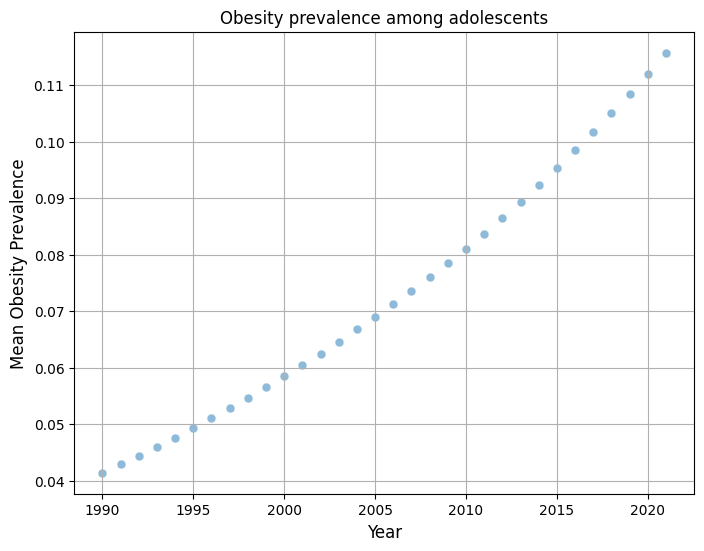

Spearman Correlation: 1.0000


In [31]:
df_filtered = df[(df['location_level'] == 'Country')] # filter country
get_mean=df_filtered.groupby('year_id')['mean_prev'].mean().reset_index() # get the mean of mean_prev per year
spearman=get_mean['year_id'].corr(get_mean['mean_prev'], method='spearman')

plt.figure(figsize=(8,6))
sns.scatterplot(
    data=get_mean,
    x='year_id',
    y='mean_prev',
    s=40,
    alpha=0.5
)
plt.title("Obesity prevalence among adolescents")
plt.xlabel("Year", fontsize=12)
plt.ylabel("Mean Obesity Prevalence", fontsize=12)
plt.grid(True)
plt.show()
print(f'Spearman Correlation: {spearman:.4f}')

The Spearman correlation coefficient was 1.0000, indicating a perfect positive relationship between year and obesity prevalence. This suggests that obesity prevalence consistently increased throughout the study period, with higher prevalence values associated with later years. 



 

However, this correlation does not mean that time itself causes obesity rates to increase. Instead, it indicates that obesity prevalence followed a consistent upward pattern, which may be influenced by other factors such as dietary changes, physical inactivity, urbanization, socioeconomic conditions, and healthcare access. 

While prevalence increased gradually during the 1990s and early 2000s, the 2010s marked the beginning of a more pronounced rise in obesity prevalence, with rates increasing more rapidly than in previous years. This accelerated growth continued through 2021, suggesting that obesity prevalence has intensified over the last decade. 

**2. How is obesity prevalence distributed across different age groups and sexes, and which subgroups exhibit higher variation or extreme values?**

A box plot is a standardized way of displaying the distribution of data based on a five-number summary. It can clearly visualize the distribution and central tendency, as well as the spread and variability of the data. Therefore, the box plot is the best choice for comparing measures of central tendency across different age groups and genders.

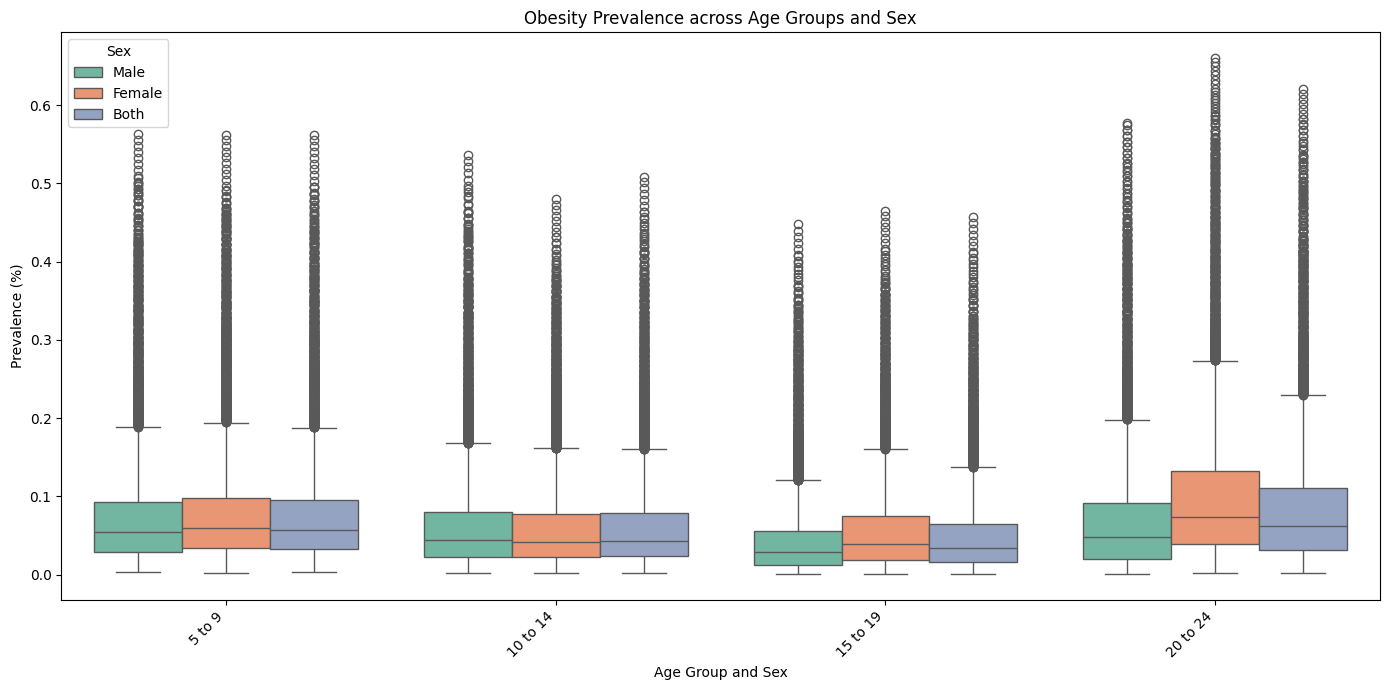

In [32]:
plt.figure(figsize=(14,7))

sns.boxplot(
    data = df,
    x = 'age_group_name',
    y = 'mean_prev',
    hue = 'Sex',
    palette =  'Set2'
)

plt.xlabel('Age Group and Sex')
plt.ylabel('Prevalence (%)')
plt.title('Obesity Prevalence across Age Groups and Sex')

plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

The median obesity prevalence `mean_prev` reaches its lowest point in the 15 to 19 age group before rising sharply to its peak in the 20 to 24 age group. Overall, young adults aged 20 to 24 exhibit significantly higher medians, interquartile ranges (IQRs), and upper whiskers than adolescents aged 5 to 19, reflecting a marked surge in obesity prevalence upon entering early adulthood. Furthermore, females consistently present slightly higher median prevalence and IQR values than males across most age groups, with the gender gap widening most prominently in the 20 to 24 bracket.

The boxplot also displays a considerable number of outliers across nearly all age and sex groups. These outliers represent observations that lie beyond 1.5 × IQR from the first or third quartile, as determined by the boxplot's outlier detection rule. Their presence does not necessarily indicate data errors. Instead, they likely reflect genuine differences in obesity prevalence among countries, arising from variations in socioeconomic conditions, healthcare access, dietary habits, physical activity levels, and other demographic or geographic factors. 

Since the dataset includes observations from many countries over multiple years, substantial variation is expected, making extreme values a natural characteristic of the data rather than anomalies. Consequently, these outliers were retained because they provide meaningful information about populations with unusually high or low obesity prevalence and contribute to a more comprehensive understanding of global obesity patterns.

**3. What countries consistently exhibit the highest obesity prevalence throughout the study period?**

Since we want to compare measures of central tendency across different countries, we will also use a box plot to visualize this data.

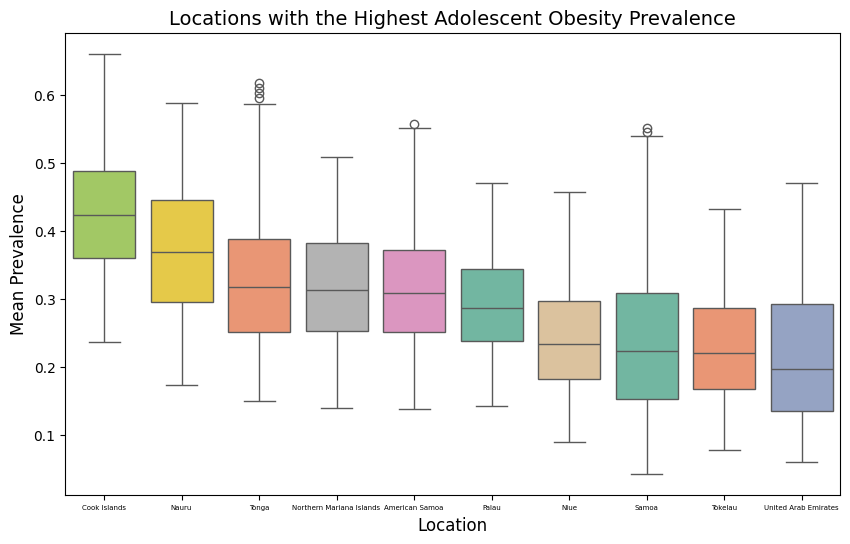

                        location_name      Mean    Median       Std
41                       Cook Islands  0.425868  0.422694  0.090816
123                             Nauru  0.373387  0.368612  0.097111
183                             Tonga  0.326201  0.317620  0.097550
132          Northern Mariana Islands  0.316756  0.312881  0.088159
3                      American Samoa  0.314250  0.308268  0.086868
..                                ...       ...       ...       ...
105                        Madagascar  0.010456  0.007482  0.008104
97   Lao People's Democratic Republic  0.010051  0.008975  0.005828
31                           Cambodia  0.008125  0.006290  0.005323
29                            Burundi  0.008011  0.006874  0.004964
200                          Viet Nam  0.005918  0.005269  0.002868

[204 rows x 4 columns]


In [33]:
top_10 = (
    df[df['location_level'].str.lower() == 'country']
    .groupby('location_name')['mean_prev']
    .mean()
    .nlargest(10)
    .index
)

df_top_countries = df[df['location_name'].isin(top_10)]

plt.figure(figsize=(10, 6))
sns.boxplot(
    data=df_top_countries,
    x='location_name',
    y='mean_prev',
    hue = 'location_name',
    palette = 'Set2',
    order=top_10
)

plt.title("Locations with the Highest Adolescent Obesity Prevalence", fontsize=14)
plt.xlabel("Location", fontsize=12)
plt.ylabel("Mean Prevalence", fontsize=12)
plt.xticks(fontsize=5)
plt.show()
country_stats=(df_filtered.groupby('location_name')['mean_prev'].agg(Mean='mean',Median='median',Std='std').reset_index().sort_values(by='Mean', ascending=False))

print(country_stats)

Obesity prevalence varies significantly across different geographic locations. The graph shows that Cook Islands leads the ranking in obesity prevalence, followed closely by Pacific Island Nations such as Nauru, and Tonga.


The high obesity prevalence observed among Pacific Island nations, such as Cook Islands, Nauru, and Tonga, may be influenced by a combination of population characteristics, environmental factors, and data collection considerations. According to the World Health Organization (WHO), in many parts of the Pacific, unhealthy food is cheap, convenient, and pushed heavily through advertising. Healthy food, on the other hand, may be increasingly difficult to get and more expensive in the face of droughts, floods and rising seas caused by climate change. 

However, the difference in the data collection process may also affect the obesity prevalence values. For smaller island nations, such as Cook Islands and Nauru, smaller population sizes may result in greater fluctuations in obesity prevalence because a smaller sample can be more sensitive to changes in individual observations.

### Research Question: What patterns can be observed in obesity prevalence trends among individuals aged 5-24 over time?


The first EDA connects to the research since this EDA is used to analyze and track the overall trend of obesity rates in people aged 5-24, which will help to analyze whether obesity rates are continuing to rise or fall, or stabilizing.

The second EDA question analyzes the relationship between age, sex, and obesity rate, which will help analyze whether demographic factors influence obesity rates. By breaking down the data into more specific age groups and sexes, the problem can identify which specific subgroups are bearing the heaviest burden or experiencing the fastest growth.



The third EDA question analyzes whether regional factors influence obesity rates. Obesity is significantly influenced by local drivers such as regional diet, national healthcare policies, socioeconomic development, and urbanization. Through data analysis, we can identify high-risk areas and provide necessary background information for analyzing whether population trends are similar globally or whether there are significant differences across different regions.


# Data Mining

### Why Clustering?

We are using clustering for this project because we want to find out:
#### Clustering answers questions like:
1. Which oountries have similar obesity prevalence?
2. Which age-sex groups show similar obesity trends?
3. Are there distinct patterns in obesity across locations?

### Select features

We select`mean_prev` and `mean_change` as the features for clustering, as these variables represent obesity prevalence levels and changes in prevalence over time. 

In [34]:
features = [
    "mean_prev",
    "mean_change",
]

# Select features
X = df[features]

Perform scaling to transform each numerical feature to the same scale.

Feature scaling was performed before applying K-Means because the algorithm relies on Euclidean distance to measure similarity between observations. Standardizing these variables prevent the clustering process to be more influenced by one feature over the other, which allows for a more balanced and accurate representation of the data.

In [35]:
# Feature scaling
scaler = StandardScaler()
scaled_data = scaler.fit_transform(X)

# convert back to dataframe
scaled_df = pd.DataFrame(scaled_data, columns=features)

# Preview
scaled_df.describe()

,mean_prev,mean_change
count,8.947200e+04,8.947200e+04
mean,-8.132106e-17,1.219816e-16
std,1.000006e+00,1.000006e+00
min,-9.330482e-01,-1.442512e+00
25%,-6.294723e-01,-7.049921e-01
50%,-3.082576e-01,-1.979058e-01
75%,2.326133e-01,3.837221e-01
max,7.870763e+00,6.152801e+00


Because K-means clustering algorithm requires the number of clusters to be specificed beforehand, we determine the optimal number of clusters using the Elbow method.

In [36]:
inertia = []

# look for the point where the decrease in inertia starts to level off
for k in range(1,11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(scaled_df)
    inertia.append(kmeans.inertia_)

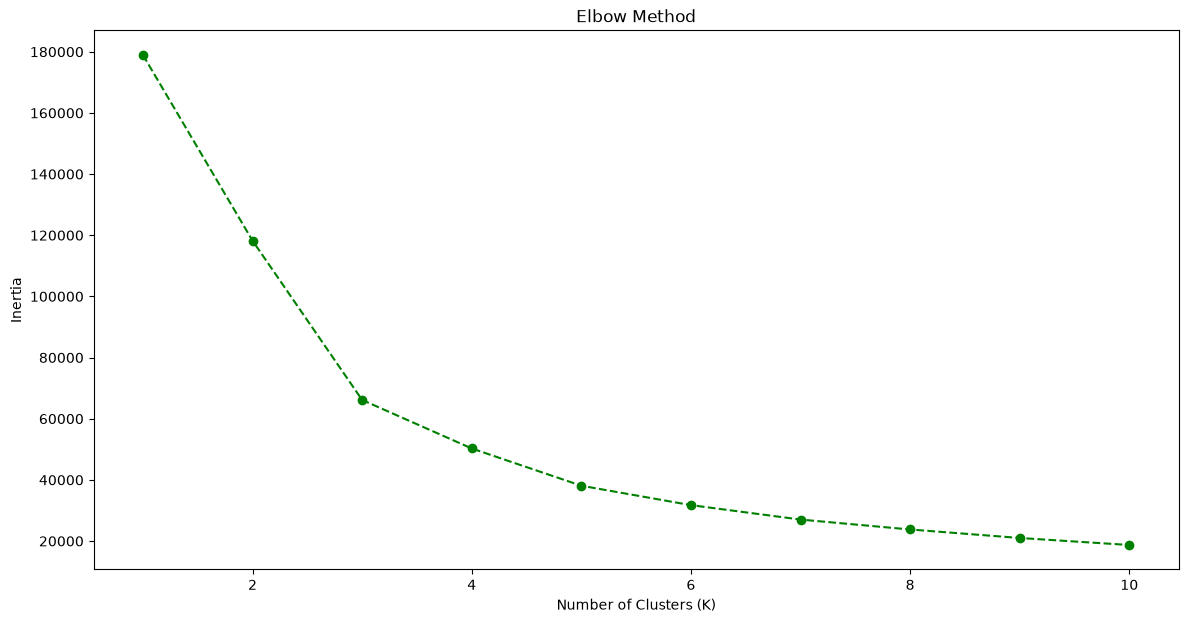

In [ ]:
plt.figure(figsize=(14,7))
plt.plot(range(1,11), inertia, marker='o', linestyle='--', color='g')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()

From this graph, the inertia starts to level off starting around K=2.

To prove how distinct our clusters are without relying on visual guesswork, we compute the Silhouette score. The Silhouette score measures how similar each observation is to its assigned cluster compared to other clusters. A higher score indicates that the clusters are more clearly separated and that the observations are appropriately grouped.

To prove how distinct our clusters are without relying on visual guesswork, we compute the Silhouette score.

In [ ]:
# compute the silhouette score to confirm the elbow result
silhouette_scores = []

for k in range(2,11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(scaled_df)

    # choose a random sample
    score = silhouette_score(
        scaled_df,
        labels,
        sample_size=10000,
        random_state=42
    )

    silhouette_scores.append(score)
    print(f"K={k}, Silhouette Score={score:.3f}")

K=2, Silhouette Score=0.521
K=3, Silhouette Score=0.503
K=4, Silhouette Score=0.381
K=5, Silhouette Score=0.394


The Silhouette score measures how similar each observation is to its assigned cluster compared to other clusters. A higher score indicates that the clusters are more clearly separated and that the observations are appropriately grouped.

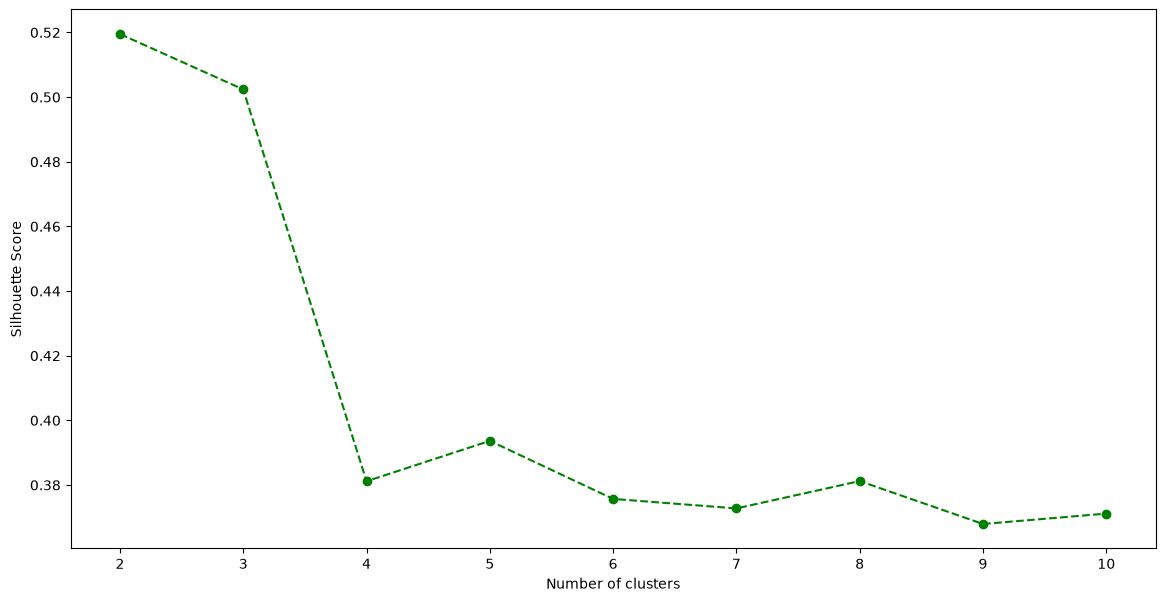

In [ ]:
plt.figure(figsize=(14,7))
plt.plot(range(2,11), silhouette_scores, marker='o', linestyle='--', color='g')
plt.xlabel('Number of clusters')
plt.ylabel('Silhouette Score')
plt.show()

Since K=2 has the highest Silhouette Score of 0.52 and the Elbow method plot shows that the inertia starts to level off starting at that point, we choose K=2 as the most optimal number of clusters.

In [ ]:
# Create the KMeans model
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)

# Fit the model and assign clusters
clusters = kmeans.fit_predict(scaled_df)

# Store the cluster labels
df["Cluster"] = clusters

### Number of Observations per Cluster

In [ ]:
df["Cluster"].value_counts()

Cluster
0    78828
1    10644
Name: count, dtype: int64

`Cluster 0` has 78,828 observations, while `Cluster 1` has 10,644 observations. This shows that most observations belong to Cluster 0, while Cluster 1 represents a smaller group.

The average values of the selected features were calculated for each cluster to compare their characteristics and obesity trends.

In [ ]:
df.groupby("Cluster")[features].mean()

,mean_prev,mean_change
Cluster,,
0,0.048782,2.830733
1,0.233220,1.751983


Cluster 0 represents observations with lower obesity prevalence but a higher increase in prevalence over time. Cluster 1 represents observations with higher obesity prevalence but a slower increase over time.

#### Which countries belong to the higher obesity cluster?

The locations assigned to Cluster 1 were examined to identify which locations commonly belong to the higher obesity prevalence group.

In [ ]:
df[df["Cluster"] == 1].groupby("location_name")["mean_prev"].mean().sort_values(ascending=False).head(10)

location_name
Cook Islands                0.425868
Nauru                       0.373387
Tonga                       0.326201
Northern Mariana Islands    0.316756
American Samoa              0.314250
Palau                       0.289943
United Arab Emirates        0.272204
Samoa                       0.270499
Niue                        0.253806
Tokelau                     0.248704
Name: mean_prev, dtype: float64

In [ ]:
df[df["Cluster"] == 0].groupby("location_name")["mean_prev"].mean().sort_values(ascending=False).head(10)

location_name
United Arab Emirates                0.117370
Niue                                0.117090
Guam                                0.116026
Kuwait                              0.115003
Tokelau                             0.112505
Micronesia (Federated States of)    0.112368
Tuvalu                              0.109620
Puerto Rico                         0.107729
United States Virgin Islands        0.107686
United States of America            0.106855
Name: mean_prev, dtype: float64

# Statistical Inference

**Growth Rate Acceleration Test**



1. **EDA Question & Context:**

    EDA Question: How has global age-standardized obesity prevalence changed from 1990 to 2021, and when did the growth rate peak?

    Context: In our EDA, the Spearman correlation indicated a strong positive trend (p = 1.0000) over the years. However, a closer look at the scatter plot reveals that growth starts to accelerate around 2010. We want to conduct a hypothesis test to determine if the annual growth rate from 2010 to 2021 is significantly higher than the growth rate from 1991 to 2009.

2. **Statement of Hypotheses**

    Null Hypothesis H0: The median annual growth rate of adolescent obesity from 2010 to 2021 is less than or equal to the median annual growth rate from 1991 to 2009.  

    Alternative Hypothesis H1: The median annual growth rate of adolescent obesity from 2010 to 2021 is significantly greater than the median annual growth rate from 1991 to 2009.  


3. **Preprocessing Steps**

- Calculated Yearly Growth: Instead of using raw prevalence numbers, we calculated the Year-over-Year (YoY) change by taking the difference between each year and the previous year:


- Divided the Data into Two Groups:

    Group 1 (1991-2009): n1 = 19 yearly change values.

    Group 2 (2010-2021): n2 = 12 yearly change values.
    

- **Important Test Values**

    Significance Level (alpha): 0.05

In [1]:
df_yearly = df.groupby('year_id')['mean_prev'].mean().reset_index()

df_yearly = df_yearly.sort_values('year_id')

df_yearly['yoy_growth'] = df_yearly['mean_prev'].diff()

# drop nan from 1990
df_growth = df_yearly.dropna(subset=['yoy_growth'])

# separate into the two time periods
group1 = df_growth[df_growth['year_id'].between(1991, 2009)]['yoy_growth'].values
group2 = df_growth[df_growth['year_id'].between(2010, 2021)]['yoy_growth'].values

# group size
print(f"Group 1 size: {len(group1)}, Group 2 size: {len(group2)}")

# one-Tailed Mann-Whitney U Test
u_stat, p_value = mannwhitneyu(group2, group1, alternative='greater')

print(f"U-statistic: {u_stat:.4f}")
print(f"p-value: {p_value:.8f}")

NameError: name 'df' is not defined

Group 1 Sample Size (1991-2009): 19 years

Group 2 Sample Size (2010-2021): 12 years

Mann-Whitney U Statistic: 228.0

p-value: 0.00000208 

Decision: Reject H0

4. **Result**

    Since our p-value (0.00000208) is much smaller than our significance level (alpha = 0.05), we reject the null hypothesis (H0).

    This gives us strong statistical evidence that the annual growth rate of global adolescent obesity was significantly higher between 2010 and 2021 than it was between 1991 and 2009. This validates our EDA plot observation: obesity prevalence didn't just increase steadily over time, but its growth actually sped up over the last decade.

**Age Group Obesity Prevalence Test**

1. **EDA Question & Context:**

    The EDA2 result showed that obesity prevalence varies across age groups, with the 20–24 age group exhibiting the highest median prevalence and the 15–19 age group exhibiting the lowest. The objective of this statistical inference is to determine whether these observed differences are statistically significant. Because the obesity prevalence data are non-normally distributed, the Kruskal–Wallis test will be used to compare the median obesity prevalence across multiple independent age groups.

1. **Why Kruskal-Wallis Test**:

    The Kruskal–Wallis test was selected because the dependent variable, obesity prevalence (mean_prev), is continuous while the independent variable, age group, consists of more than two independent groups. The obesity prevalence data were found to be non-normally distributed and positively-skewed based on the exploratory data analysis. Since the normality assumption required for One-Way ANOVA is violated, the Kruskal–Wallis test, a non-parametric alternative, is more appropriate because it compares the medians of multiple independent groups without assuming normality.

2. **Hypotheses**

    **Null Hypothesis:** The median of obesity prevalence is the same across all age groups.

    **Alternative Hypothesis:** At least one age group has a different median of obesity prevalence.

3. **Preprocessing Steps**

    The obesity prevalence values were grouped according to age group. A significance level of α = 0.05 will be used.

In [ ]:
df_age = df[['age_group_name', 'mean_prev']]

# group them by age group
groups = [
    group['mean_prev'].values
    for _, group in df_age.groupby('age_group_name')
]

H_stat, p_value = kruskal(*groups)

print(f"H-statistic: {H_stat:.4f}")
print(f"p-value: {p_value:.4f}")

4. **Result**

    The Kruskal–Wallis test yielded an **H-statistic of 4611.6863** and a **p-value approximately 0.0000**.

    Since the p-value < α (0.05), the **null hypothesis is rejected**.

    Therefore, there is sufficient statistical evidence to conclude that **obesity prevalence differs significantly among the age groups**. This finding supports the results of the EDA 2, where the boxplot showed differences in the median obesity prevalence across age groups, with individuals aged 20–24 years exhibiting the highest median obesity prevalence and aged 15-19 years having the lowest.

**Male and Female Obesity Prevalence Test**

1. **EDA Question & Context:**

    The EDA 2 also showed that obesity prevalence differs between males and females, with females generally exhibiting slightly higher median obesity prevalence across most age groups. The objective of this statistical inference is to determine whether the observed difference in obesity prevalence between the two sexes is statistically significant. Since the obesity prevalence data are non-normally distributed, the Mann–Whitney U test was employed as the appropriate non-parametric alternative to the unpaired t-test for comparing the median obesity prevalence between two independent groups.

    

1. **Why Mann-Whitney U test**:

    The Mann–Whitney U test assumes that the observations are independent, the dependent variable is measured on at least an ordinal scale, and the two groups being compared are independent of one another. Since obesity prevalence (mean_prev) is a continuous variable, while sex consists of two independent groups: males and females. The EDA indicated that the obesity prevalence data are non-normally distributed and positively-skewed, violating the normality assumption required for the unpaired t-test. Consequently, the Mann–Whitney U test was employed as the appropriate non-parametric alternative because it compares the medians of two independent groups without assuming normality.

2. **Statement of Hypotheses**

    **Null Hypothesis:** The median obesity prevalence is the same for males and females.

    **Alternative Hypothesis:** The median obesity prevalence differs between males and females.

3. **Preprocessing Steps**

    The dataset was separated into Male and Female groups. A significance level of α = 0.05 will be use.

In [ ]:
male = df[df['Sex'] == 'Male']['mean_prev']
female = df[df['Sex'] == 'Female']['mean_prev']

U_stat, p_value = mannwhitneyu(male, female, alternative='two-sided')

print(f"U-statistic: {U_stat:.4f}")
print(f"p-value: {p_value:.4f}")

4. **Result**

    The Mann–Whitney U test yielded a **U-statistic of 388,785,400** with **p-value approximately 0.0000**. 

    Using a significance level of α = 0.05, the **null hypothesis was rejected**. Therefore, there is sufficient statistical evidence to conclude that obesity prevalence differs significantly between males and females. This supports the findings from the exploratory data analysis that females generally exhibit slightly higher median obesity prevalence than males.

# SUMMARY, CONCLUSIONS, AND RECOMMENDATIONS

For this study, we examined the Global Burden of Disease (GBD) 2021 estimates about obesity prevalence among individuals aged 5 to 24 from the year 1990 to 2021. To investigate obesity trends over time and differences across age, sex, and countries, we conducted exploratory data analysis (EDA), K-Means clustering, and non-parametric hypothesis testing. 

# SUMMARY OF KEY FINDINGS

Temporal trends. Exploratory data analysis showed a continuous increase in global youth obesity prevalence from 1990 to 2021, with a perfect positive Spearman correlation (ρ = 1.0000) between year and mean prevalence. A one-tailed Mann Whitney U test confirmed that the annual growth rate was significantly higher during 2010–2021 than 1991–2009 (U = 228.0, p = 0.00000208), indicating that obesity prevalence accelerated in the past decade. 

Demographic patterns. The boxplot analysis showed obesity burden is not equal across different ages and sexes, with the 15-19 age group showing the lowest prevalence while 20-24 showing the highest. Females also exhibited a higher median prevalence than males in almost all age groups. These differences were confirmed by the Kruskal–Wallis test across age groups (H = 4611.6863, p < 0.05) and the Mann–Whitney U test between males and females (U = 388,785,400, p < 0.05). 

Geographic patterns. The obesity rates also varied a lot depending on the location. Cook Islands got the highest mean prevalence (2.6%), followed by other Pacific Island countries like Nauru and Tonga. We decided not to remove these super high numbers as outliers because they are real observations that reflect actual environmental and socioeconomic problems mentioned by the WHO, like having hard access to healthy food and too much marketing of unhealthy alternatives.

Data mining insights. We did K Means clustering using standardized mean_prev and mean_change variables, and K = 3 turned out to be the best number of clusters (supported by both the elbow method and silhouette analysis). This grouping split our data into distinct profiles based on current prevalence level and how fast it changes over time. This proves that global youth obesity isn't just one single trend happening everywhere, but rather a mix of patterns - some places have high obesity with slow change, while others are getting worse super fast.

# CONCLUSIONS

Overall, all our evidence gives a clear answer to our research question: youth obesity among people aged 5–24 has been steadily going up from 1990 to 2021, it got even faster starting 2010, and it really depends on demographic and geographic factors.

First, the pattern over time is super visible and statistically proven. That perfect Spearman correlation shows that the increase never stopped during the whole study period. Plus, the Mann Whitney U test gives real statistical proof that the post-2010 period is a much faster phase of increase, not just a continuation of the same speed observed in the 1990s and 2000s.

Second, demographics matter a lot. The significant results from the Kruskal Wallis and Mann Whitney U tests prove that age and sex are not just incidental details. The jump from late adolescence (15–19) to young adulthood (20–24) is where the largest increase happens, and females consistently experience somewhat higher prevalence. These patterns suggest that interventions timed around school to adulthood transitions and tailored to sex specific risk profiles could really help a lot.

Third, location is a huge defining dimension of the problem. Having the highest obesity rates in Pacific Island nations shows that obesity trends are not uniform worldwide. Our clustering also proves this heterogeneity by dividing groups based on both their level and speed of change. Basically, youth obesity is a global issue with locally concentrated hotspots, not just a single global average moving together.

Lastly, all conclusions must be interpreted within the limitations of using modeled GBD estimates. The data relies on spatiotemporal regression where direct measurements are sparse, and self-reported height and weight in some source data might introduce residual bias. But still, since our EDA, clustering, and hypothesis tests all match up, we can be confident in the overall story the data is telling us.

# RECOMMENDATIONS

Based on what we found, here are some actionable steps recommended for policymakers, public health practitioners, and future researchers:

Prioritize the post 2010 acceleration in policy design. Because growth rates after 2010 are statistically higher than in earlier decades, prevention and early intervention programs should be scaled up urgently instead of just assuming a gradual long-term trend will self-correct.

Target the 15–24 transition period. Programs in high schools, universities, and early workforce settings should address diet, physical activity, and mental health support at the age where prevalence rises most sharply - from the relatively lower 15–19 group into the peak 20–24 group.

Incorporate sex specific strategies. Given significantly higher prevalence among females, interventions should evaluate gender specific drivers like differing activity patterns, body image pressures, or access to nutrition programs rather than just applying a one size fits all messaging.

Deploy geographically targeted interventions in high burden regions. Pacific Island nations and similar hotspots require localized action on food environments, import policies, advertising regulations, and climate resilient access to nutritious food - aligned with WHO guidance on the Pacific obesity crisis.

Use cluster based risk stratification for resource allocation. The three cluster structure suggests that public health resources should distinguish between populations with high current prevalence, populations with rapid worsening trends, and lower burden groups allocating prevention, treatment, and monitoring accordingly.

Extend the analysis with follow-up research. Future work could link GBD estimates to national policy indicators, evaluate subnational variations within larger countries, and incorporate forecast data cautiously to stress test whether current trajectories imply further acceleration without intervention.

In conclusion, the data presents a very clear and concerning story, adolescent and young adult obesity has gotten worse globally, sped up in recent years, and falls unevenly across age, sex, and region. Addressing this challenge requires interventions that are time sensitive, demographically tailored, and geographically precise matching the exact patterns our analysis revealed.

# References & Disclosures

Obesity: Health consequences of being overweight. (n.d.). https://www.who.int/news-room/questions-and-answers/item/obesity-health-consequences-of-being-overweight

https://www.thelancet.com/journals/lancet/article/PIIS0140-6736(25)00397-6/fulltext

https://ghdx.healthdata.org/record/ihme-data/gbd-2021-child-adolescent-obesity-overweight-prevalence-1990-2050

WHO. (2024). Study finds Pacific accounts for 9 of the 10 most obese countries in the world. In www.who.int. https://www.who.int/westernpacific/about/how-we-work/pacific-support/news/detail/04-03-2024-study-finds-pacific-accounts-for-9-of-the-10-most-obese-countries-in-the-world



# Generative AI Use

The group used Grammarly to fix any grammar issues, rest assured, AI was not used in any code block nor Text Blocks. Furthermore, AI was used to do research on the test outside of our classroom curriculum.